Sentiment Analysis on IMDB Movie Reviews Using Machine Learning
## Project Overview
This project aims to classify IMDB movie reviews as Positive or Negative using Natural Language Processing (NLP) and Machine Learning.
The project includes:
- Data Understanding
- Exploratory Data Analysis (EDA)
- Text Cleaning
- Feature Extraction using TF-IDF
- Model Training
- Cross Validation
- Model Evaluation
- Performance Comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Importing Required Libraries
In this step, we import the libraries required for data manipulation, visualization, machine learning, and model evaluation.

- Pandas → Load and manipulate datasets.
- NumPy → Perform numerical computations.
- Matplotlib & Seaborn → Create visualizations.
- train_test_split → Split data into training and testing sets.
- cross_val_score → Evaluate the model using Cross Validation.
- TfidfVectorizer → Convert text into numerical features.
- Logistic Regression & Linear SVM → Train sentiment classification models.
- Metrics → Evaluate model performance.

## Loading the Dataset
The IMDB movie review dataset is loaded using the Pandas library. This dataset contains movie reviews along with their corresponding sentiment labels (Positive or Negative).

The dataset has two columns:
- review → Movie review written by a viewer.
- sentiment → Sentiment label (Positive or Negative).

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### Dataset Size
The dataset contains **50,000 movie reviews** and **2 columns**.

- Rows: 50,000
- Columns: 2

A large dataset helps the machine learning model learn better patterns for sentiment classification.

In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

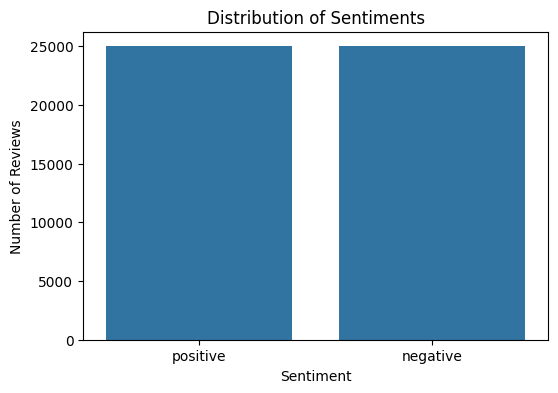

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## Sentiment Distribution
The distribution of sentiments was analyzed to determine whether the dataset is balanced or imbalanced.
### Observation
- Positive Reviews: 25,000
- Negative Reviews: 25,000

The dataset is perfectly balanced, with an equal number of positive and negative reviews.
### Conclusion
Since the dataset is already balanced, no resampling techniques such as undersampling or oversampling are required. Using the complete balanced dataset helps preserve all available information and improves the reliability of the machine learning model.

## Review Length Analysis
In this step, we calculate the length of each review.
Review length helps us understand how much users typically write while expressing their opinions. Later, we will compare the review lengths for positive and negative sentiments.

In [9]:
df["review_length"] = df["review"].apply(len)
df[["review", "review_length"]].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926
3,Basically there's a family where a little boy ...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317


In [10]:
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

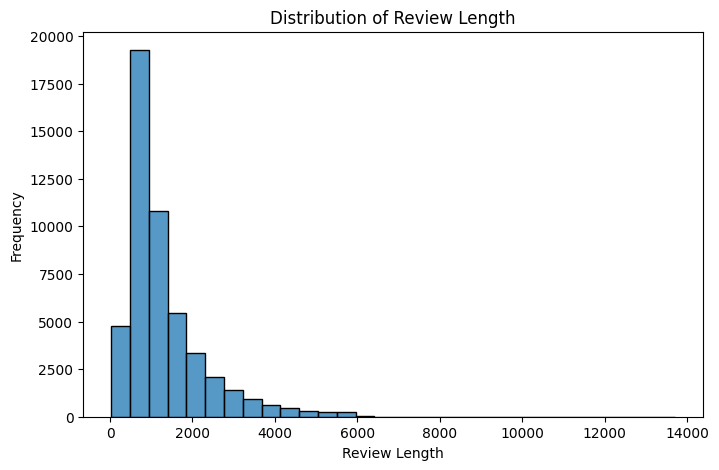

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["review_length"], bins=30)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

## Review Length Analysis - Observation
The average review length is approximately 1309 characters. The minimum review length is 32 characters, while the maximum length reaches 13,704 characters.

The large difference between minimum and maximum values indicates that review lengths vary significantly. Some users provide short opinions, while others write detailed reviews.

This variation should be considered during text preprocessing and model training.

In [12]:
df.groupby("sentiment")["review_length"].mean()

sentiment
negative    1294.06436
positive    1324.79768
Name: review_length, dtype: float64

## Review Length Comparison by Sentiment
The average review length was compared between positive and negative reviews.
### Observation:

- Negative reviews have an average length of approximately 1294 characters.
- Positive reviews have an average length of approximately 1325 characters.

Positive reviews are slightly longer than negative reviews; however, the difference is small. Therefore, review length alone may not be a strong feature for sentiment classification. The actual words and context in the reviews are more important for prediction.

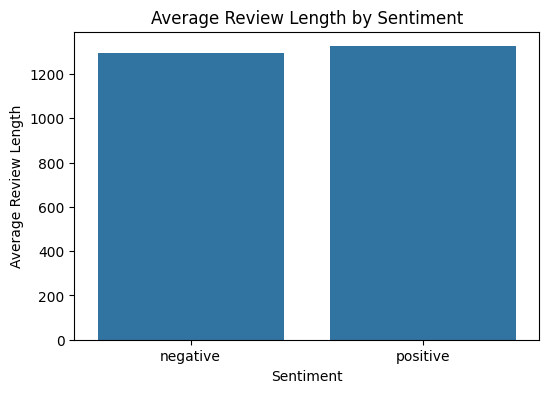

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=df.groupby("sentiment")["review_length"].mean().index,
    y=df.groupby("sentiment")["review_length"].mean().values
)
plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")
plt.show()

## Text Cleaning
Text preprocessing is an important step in Natural Language Processing (NLP).

Raw movie reviews contain HTML tags, special characters, and inconsistent capitalization. These unnecessary elements are removed to make the text suitable for machine learning algorithms.

In [14]:
import re
def clean_text(text): 
    # Remove HTML tags
    text = re.sub('<.*?>', '', text) 
    # Convert text to lowercase
    text = text.lower()   
    # Remove special characters and numbers
    text = re.sub('[^a-zA-Z]', ' ', text)  
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

In [15]:
df["clean_review"] = df["review"].apply(clean_text)
df.head()

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,positive,1761,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,998,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,926,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,748,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter mattei s love in the time of money is a...


## Splitting the Dataset

The dataset is divided into training and testing sets. The training data is used to learn patterns from the reviews, while the test data is kept separate to evaluate how well the trained model performs on unseen reviews.

A stratified split is used to maintain the same proportion of positive and negative reviews in both sets.

In [16]:
from sklearn.model_selection import train_test_split
X = df["clean_review"]
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


## TF-IDF Feature Extraction

Machine learning models cannot directly process raw text. Therefore, TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the movie reviews into numerical features.

TF-IDF gives higher importance to words that are informative within the reviews and lower importance to very common words.

English stopwords are removed during this process to reduce unnecessary features.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (40000, 10000)
Testing TF-IDF shape: (10000, 10000)


## Model Selection and Cross-Validation

Several supervised machine learning classification models are evaluated to determine which model is most suitable for sentiment classification.

Instead of relying on a single train-test split for model selection, stratified cross-validation is performed on the training data. This provides a more reliable estimate of model performance by evaluating each model across multiple folds.
The test set remains untouched until the final evaluation.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [ ]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=cv,
        scoring="accuracy"
    )
    cv_results[name] = scores
    print(f"{name}:")
    print(f"Fold scores: {scores}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Standard deviation: {scores.std():.4f}")
    print("-" * 50)

Logistic Regression:
Fold scores: [0.883125 0.889625 0.889875 0.89075  0.891875]
Mean accuracy: 0.8891
Standard deviation: 0.0031
--------------------------------------------------
Linear SVM:
Fold scores: [0.877125 0.88075  0.87725  0.87875  0.8855  ]
Mean accuracy: 0.8799
Standard deviation: 0.0031
--------------------------------------------------
Naive Bayes:
Fold scores: [0.859375 0.85275  0.855    0.855375 0.860125]
Mean accuracy: 0.8565
Standard deviation: 0.0028
--------------------------------------------------


## Cross-Validation Model Comparison

The models were compared using 5-fold stratified cross-validation on the training dataset.

Logistic Regression achieved the highest mean accuracy of approximately 88.91%, followed by Linear SVM at approximately 87.99%. Naive Bayes achieved 85.65%, while Decision Tree performed lowest with 71.91%.

Based on cross-validation performance, Logistic Regression was selected as the best-performing model for final evaluation.

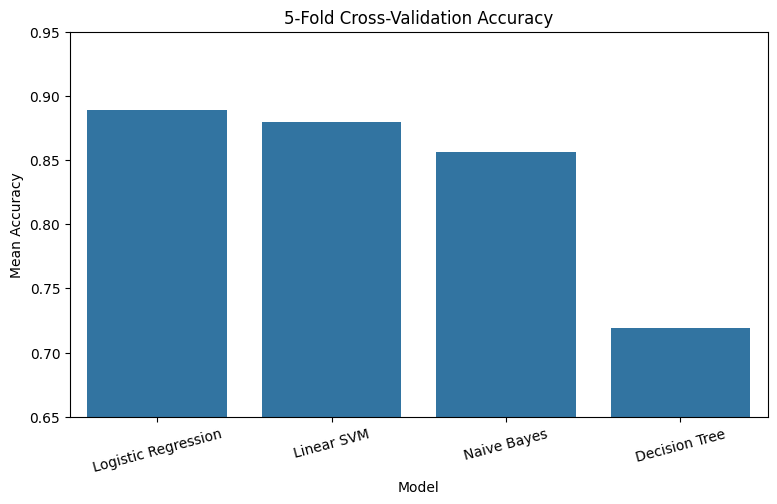

In [ ]:
cv_mean = {
    name: scores.mean()
    for name, scores in cv_results.items()
}

plt.figure(figsize=(9, 5))

sns.barplot(
    x=list(cv_mean.keys()),
    y=list(cv_mean.values())
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")

plt.ylim(0.65, 0.95)
plt.xticks(rotation=15)

plt.show()

Train our Best Model.......

In [ ]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = best_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8946


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4420  580]
 [ 474 4526]]


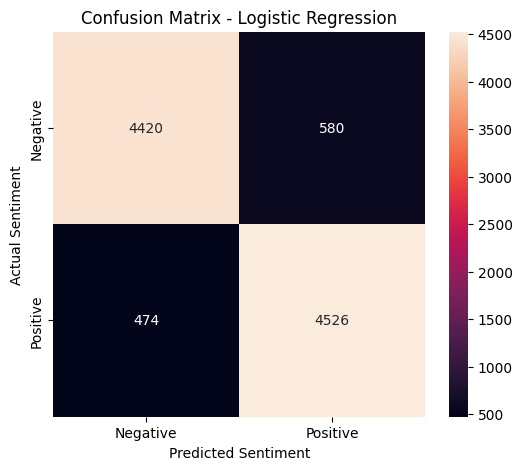

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

## Final Model Evaluation

The selected Logistic Regression model was trained on the complete training set and evaluated on 10,000 previously unseen test reviews.

The model achieved an accuracy of approximately 89%.

The classification report shows balanced performance across both sentiment classes. The F1-score was 0.89 for negative reviews and 0.90 for positive reviews.

The confusion matrix shows that 4,420 negative reviews and 4,526 positive reviews were correctly classified. A total of 580 negative reviews were incorrectly classified as positive, while 474 positive reviews were incorrectly classified as negative.

Overall, the results indicate that Logistic Regression combined with TF-IDF provides a strong baseline for binary sentiment classification on the IMDB dataset.

## Real-World Sentiment Prediction

To demonstrate the practical use of the trained sentiment analysis model, we test it on new movie reviews that were not part of the original dataset.

The same preprocessing and TF-IDF transformation used during training are applied to the new reviews before generating predictions.

In [ ]:
new_reviews = [
    "This movie was absolutely fantastic. The acting was brilliant and I loved every minute of it.",
    "The movie was boring, poorly written, and a complete waste of time.",
    "I really enjoyed this film. The story was engaging and the performances were excellent.",
    "I did not enjoy this movie. The plot was predictable and the acting was disappointing."
]

# Clean the new reviews
clean_new_reviews = [clean_text(review) for review in new_reviews]

# Convert reviews using the already fitted TF-IDF vectorizer
new_reviews_tfidf = tfidf.transform(clean_new_reviews)

# Predict sentiment
predictions = best_model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", prediction)
    print("-" * 70)

Review: This movie was absolutely fantastic. The acting was brilliant and I loved every minute of it.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: The movie was boring, poorly written, and a complete waste of time.
Predicted Sentiment: negative
----------------------------------------------------------------------
Review: I really enjoyed this film. The story was engaging and the performances were excellent.
Predicted Sentiment: positive
----------------------------------------------------------------------
Review: I did not enjoy this movie. The plot was predictable and the acting was disappointing.
Predicted Sentiment: negative
----------------------------------------------------------------------


## Important Words Associated with Sentiment

Logistic Regression assigns a coefficient to each TF-IDF feature. Positive coefficients indicate words that are more strongly associated with positive sentiment, while negative coefficients indicate words associated with negative sentiment.

Examining these coefficients provides an interpretable view of the words that contribute to sentiment predictions.

In [ ]:
feature_names = tfidf.get_feature_names_out()

coefficients = best_model.coef_[0]

# Most positive words
positive_indices = coefficients.argsort()[-15:][::-1]

# Most negative words
negative_indices = coefficients.argsort()[:15]

positive_words = feature_names[positive_indices]
negative_words = feature_names[negative_indices]

print("Top Positive Words:")
print(positive_words)

print("\nTop Negative Words:")
print(negative_words)

Top Positive Words:
['great' 'excellent' 'best' 'perfect' 'amazing' 'wonderful' 'loved'
 'enjoyed' 'hilarious' 'favorite' 'fun' 'brilliant' 'today' 'highly'
 'enjoyable']

Top Negative Words:
['worst' 'waste' 'awful' 'bad' 'boring' 'poor' 'terrible' 'worse' 'poorly'
 'dull' 'horrible' 'disappointment' 'fails' 'disappointing' 'instead']


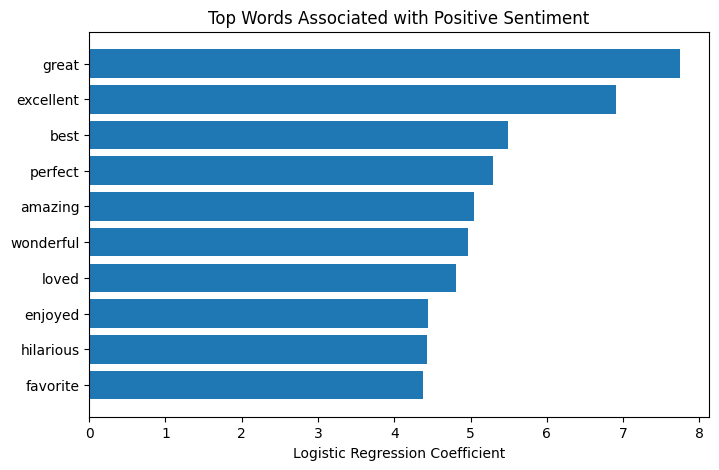

In [ ]:
top_positive = positive_indices[:10]
top_negative = negative_indices[:10]

plt.figure(figsize=(8, 5))

plt.barh(
    feature_names[top_positive][::-1],
    coefficients[top_positive][::-1]
)

plt.title("Top Words Associated with Positive Sentiment")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

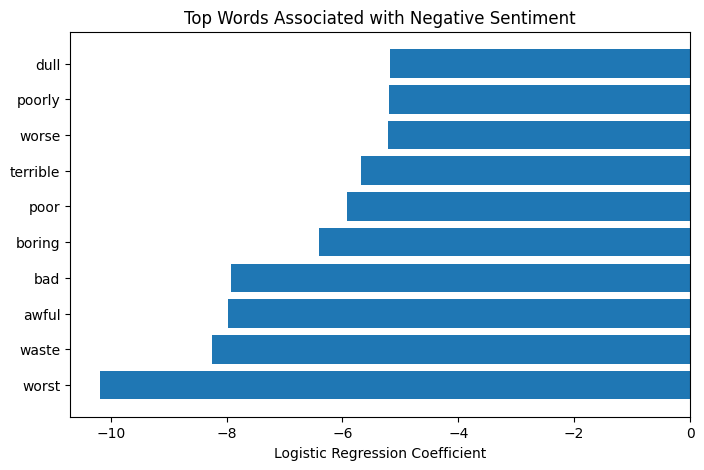

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_names[top_negative],
    coefficients[top_negative]
)

plt.title("Top Words Associated with Negative Sentiment")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

### Interpretation

The most influential positive features include words such as "great", "excellent", "amazing", "wonderful", and "enjoyed". These words have positive coefficients and therefore contribute toward positive sentiment predictions.

The most influential negative features include "worst", "waste", "awful", "boring", "terrible", and "disappointing". These features have negative coefficients and contribute toward negative sentiment predictions.

This analysis provides interpretability by showing which words the Logistic Regression model associates strongly with each sentiment class.

# Conclusion

In this project, sentiment analysis was performed on 50,000 IMDB movie reviews to classify reviews as positive or negative.

The dataset was explored to understand its structure, sentiment distribution, and review-length patterns. Text preprocessing was performed to remove HTML tags, convert text to lowercase, remove unnecessary characters, and normalize whitespace.

TF-IDF was used to transform textual reviews into numerical features. Four machine learning models were compared using 5-fold stratified cross-validation: Logistic Regression, Linear SVM, Naive Bayes, and Decision Tree.

Logistic Regression achieved the best cross-validation performance with a mean accuracy of approximately 88.91%. The model was then trained on the complete training set and evaluated on 10,000 unseen test reviews, achieving approximately 89% accuracy.

The model also demonstrated balanced performance across positive and negative classes, with F1-scores of 0.90 for positive reviews and 0.89 for negative reviews.

Finally, the model was tested on new movie reviews and successfully demonstrated practical sentiment prediction. Important positive and negative features were also examined using Logistic Regression coefficients, providing insight into the words influencing sentiment classification.

Overall, the results demonstrate that TF-IDF combined with Logistic Regression provides an effective and interpretable approach for binary sentiment analysis of movie reviews.